# 01 - Fetch & Explore Materials Project Data

This notebook fetches oxide materials data from the Materials Project API
and performs initial exploratory data analysis.

**FAIR principles covered:**
- **F**indable: Data stored with structured metadata
- **A**ccessible: Retrieved via public API with authentication
- **I**nteroperable: Standard pandas DataFrames, CSV output
- **R**eusable: Documented provenance and license

In [1]:
import os
import json
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

ROOT = Path('..').resolve()
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'

## 1. Connect to Materials Project

In [2]:
from mp_api.client import MPRester

api_key = os.getenv('MP_API_KEY')
if not api_key:
    raise ValueError('MP_API_KEY not found in .env file')

mpr = MPRester(api_key)
print('Connected to Materials Project API')

Connected to Materials Project API


## 2. Fetch Oxide Materials Data

We query for materials containing oxygen, retrieving key properties:
- Formation energy per atom
- Band gap
- Crystal structure (space group)
- Density

In [3]:
doc = mpr.materials.summary.search(
    elements=["O"],
    num_elements=(2, 3),
    fields=[
        "material_id",
        "formula_pretty",
        "symmetry",
        "formation_energy_per_atom",
        "band_gap",
        "density",
        "nsites",
        "is_stable",
        "energy_above_hull",
    ],
    chunk_size=1000,
    num_chunks=1,
)

print(f'Fetched {len(doc)} materials')
print(f'Fields available: {list(doc[0].model_fields.keys())}')

Retrieving SummaryDoc documents:   0%|          | 0/1000 [00:00<?, ?it/s]

Fetched 1000 materials
Fields available: ['band_gap', 'material_id', 'symmetry', 'energy_above_hull', 'is_stable', 'formula_pretty', 'nsites', 'formation_energy_per_atom', 'density', 'fields_not_requested', 'unavailable_fields']


/tmp/ipykernel_627349/862331550.py:20: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  print(f'Fields available: {list(doc[0].model_fields.keys())}')


## 3. Convert to DataFrame & Explore

In [4]:
records = []
for entry in doc:
    records.append({
        'material_id': str(entry.material_id),
        'formula': entry.formula_pretty,
        'space_group': entry.symmetry.symbol if entry.symmetry else None,
        'crystal_system': entry.symmetry.crystal_system if entry.symmetry else None,
        'formation_energy_per_atom': entry.formation_energy_per_atom,
        'band_gap': entry.band_gap,
        'density': entry.density,
        'nsites': entry.nsites,
        'is_stable': entry.is_stable,
        'energy_above_hull': entry.energy_above_hull,
    })

df = pd.DataFrame(records)
print(f'DataFrame shape: {df.shape}')
df.head(10)

DataFrame shape: (1000, 10)


,material_id,formula,space_group,crystal_system,formation_energy_per_atom,band_gap,density,nsites,is_stable,energy_above_hull
0,mp-1523737,NClO,P2_1/c,Monoclinic,0.090138,2.0666,1.812475,12,False,0.159467
1,mp-1567687,V3OF7,C2/m,Monoclinic,-3.022540,1.3813,3.215234,22,False,0.096936
2,mp-1568124,V3OF7,P-1,Triclinic,-3.014306,1.3700,3.227839,22,False,0.105170
3,mp-1568829,Fe4OF6,P1,Triclinic,-2.323263,2.6285,4.420859,22,False,0.065270
4,mp-1569012,Fe4OF6,Pm,Monoclinic,-2.313648,2.4446,4.482592,22,False,0.074885
5,mp-1574300,V2OF5,P1,Triclinic,-3.042165,1.8126,3.208064,24,False,0.004112
6,mp-1574993,V2OF5,P3_1,Trigonal,-3.044635,0.5308,3.567042,24,False,0.001643
7,mp-1638869,Fe4OF6,C2/c,Monoclinic,-2.340081,2.7850,4.400628,22,False,0.048452
8,mp-1648259,V2OF5,P3_2,Trigonal,-3.046278,0.5952,3.565811,24,True,0.000000
9,mp-1652491,Fe4OF6,P-1,Triclinic,-2.339452,2.7748,4.406342,22,False,0.049081


In [5]:
df.describe()

,formation_energy_per_atom,band_gap,density,nsites,energy_above_hull
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-1.668049,1.153194,5.002279,22.515000,0.381494
std,1.154707,1.416739,2.594580,22.751602,0.680760
min,-4.342683,0.000000,0.257308,2.000000,0.000000
25%,-2.541806,0.000000,3.340877,6.000000,0.042250
50%,-1.800349,0.687900,4.376042,16.000000,0.130973
75%,-0.933575,1.886500,5.894596,30.000000,0.345472
max,2.697567,8.168100,18.387812,116.000000,4.695925


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   material_id                1000 non-null   str    
 1   formula                    1000 non-null   str    
 2   space_group                1000 non-null   str    
 3   crystal_system             1000 non-null   object 
 4   formation_energy_per_atom  1000 non-null   float64
 5   band_gap                   1000 non-null   float64
 6   density                    1000 non-null   float64
 7   nsites                     1000 non-null   int64  
 8   is_stable                  1000 non-null   bool   
 9   energy_above_hull          1000 non-null   float64
dtypes: bool(1), float64(4), int64(1), object(1), str(3)
memory usage: 89.4+ KB


## 4. Visualize Key Properties

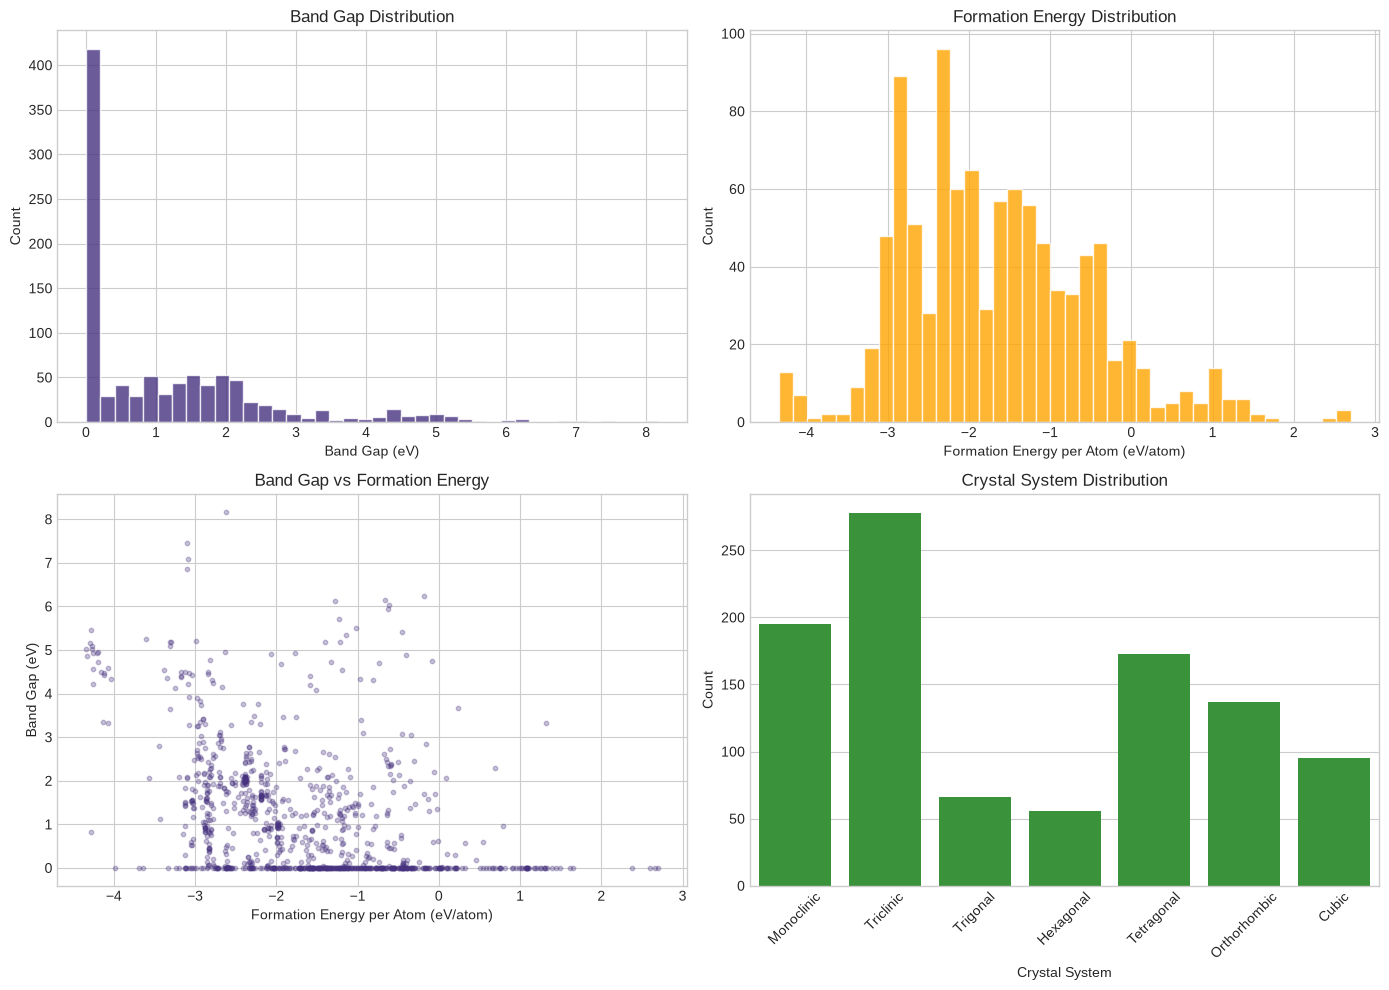

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Band gap distribution
axes[0, 0].hist(df['band_gap'], bins=40, edgecolor='white', alpha=0.8)
axes[0, 0].set_xlabel('Band Gap (eV)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Band Gap Distribution')

# Formation energy distribution
axes[0, 1].hist(df['formation_energy_per_atom'].dropna(), bins=40, edgecolor='white', alpha=0.8, color='orange')
axes[0, 1].set_xlabel('Formation Energy per Atom (eV/atom)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Formation Energy Distribution')

# Band gap vs formation energy
valid = df.dropna(subset=['formation_energy_per_atom', 'band_gap'])
axes[1, 0].scatter(valid['formation_energy_per_atom'], valid['band_gap'], alpha=0.3, s=10)
axes[1, 0].set_xlabel('Formation Energy per Atom (eV/atom)')
axes[1, 0].set_ylabel('Band Gap (eV)')
axes[1, 0].set_title('Band Gap vs Formation Energy')

# Crystal system counts
cs_data = df['crystal_system'].dropna()
sns.countplot(data=cs_data.to_frame(), x='crystal_system', ax=axes[1, 1], color='tab:green')
axes[1, 1].set_xlabel('Crystal System')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Crystal System Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'initial_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Data (FAIR: Interoperable & Reusable)

In [8]:
csv_path = DATA_PROCESSED / 'mp_oxides_clean.csv'
df.to_csv(csv_path, index=False)
print(f'Saved {len(df)} records to {csv_path}')

Saved 1000 records to /home/hossein/fair-data-learning/data/processed/mp_oxides_clean.csv


In [9]:
provenance = {
    'source': 'Materials Project',
    'query': {
        'elements': ['O'],
        'num_elements': [2, 3],
        'fields': ['material_id', 'formula_pretty', 'symmetry', 'formation_energy_per_atom', 'band_gap', 'density', 'nsites', 'is_stable', 'energy_above_hull']
    },
    'fetch_date': datetime.now().isoformat(),
    'num_materials': len(df),
    'license': 'CC-BY-4.0',
    'notebook': '01_fetch_explore_mp_data.ipynb'
}

with open(DATA_PROCESSED / 'provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)

print('Provenance saved.')

Provenance saved.
